# Shov-JEPA v4: Spatial Structure Prediction (Path 1)
Screen → 4×4 grid → per-cell features → mask 50% → predict masked.

~5 min. Press **Run all**.

In [1]:
%%javascript
function ClickConnect(){ document.querySelector('colab-connect-button')?.click(); }
setInterval(ClickConnect, 60000);

<IPython.core.display.Javascript object>

In [2]:
!pip install datasets -q
import torch, os, json, time, copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 1. Collect Spatial Grid Features

In [3]:
import datasets as dsets

DATA_DIR = '/content/shov_v4'
os.makedirs(DATA_DIR, exist_ok=True)
TARGET = 200
GRID = 4
CELL_FEATS = 8

FUNNEL_P = ['feed','stream','timeline','browse','news','video','media','story','content',
  'discover','explore','watch','recommend','trending','popular','gallery','photo',
  'subreddit','channel','episode','series','article','scroll','swipe','home','main',
  'list','catalog','playlist','player']
DOORS_P = ['setting','config','preference','about','detail','form','edit','add','create',
  'signup','login','auth','register','profile','info','help','faq','terms','privacy',
  'option','permission','tutorial','onboard','welcome','picker','select','choose',
  'confirm','checkout','payment','review','account','setup','wizard','step','complete','submit']
EXCL = ['chat','message','inbox','conversation','notification','social','comment','reply',
  'thread','group','contact','call','voip','compose','mail','email']

def classify(n):
    a = n.lower()
    if any(p in a for p in EXCL): return 'skip'
    f = sum(1 for p in FUNNEL_P if p in a)
    d = sum(1 for p in DOORS_P if p in a)
    return 'funnel' if f > d else ('doors' if d > f else 'skip')

def flatten_nodes(activity):
    nodes = [{k: v for k, v in activity['root'].items()}]
    for child_group in activity.get('children', []):
        if not isinstance(child_group, dict): continue
        sample_key = 'klass' if 'klass' in child_group else list(child_group.keys())[0]
        sample_val = child_group[sample_key]
        if not isinstance(sample_val, list):
            nodes.append(child_group); continue
        n = len(sample_val)
        for i in range(n):
            node = {}
            for k, v in child_group.items():
                node[k] = v[i] if isinstance(v, list) and len(v) == n else v
            nodes.append(node)
    return nodes

def nodes_to_grid(nodes, sw=1440, sh=2560, grid=4):
    cw, ch = sw/grid, sh/grid
    g = np.zeros((grid, grid, CELL_FEATS), dtype=np.float32)
    for node in nodes:
        bounds = node.get('bounds', None)
        if not bounds or not isinstance(bounds, list) or len(bounds) != 4: continue
        x1,y1,x2,y2 = bounds
        if x2<=x1 or y2<=y1: continue
        cs = max(0, int(x1/cw)); ce = min(grid-1, int((x2-1)/cw))
        rs = max(0, int(y1/ch)); re = min(grid-1, int((y2-1)/ch))
        klass = str(node.get('klass','')).lower()
        rid = str(node.get('resource_id','') or '').lower()
        for r in range(rs, re+1):
            for c in range(cs, ce+1):
                g[r,c,0] += 1
                if node.get('clickable', False): g[r,c,1] += 1
                if node.get('scrollable_vertical', False): g[r,c,2] += 1
                if node.get('scrollable_horizontal', False): g[r,c,3] += 1
                if node.get('adapter_view', False): g[r,c,4] += 1
                if any(x in rid for x in ['toolbar','action_bar','back','navigate_up','nav','tab','bottom']): g[r,c,5] += 1
                if 'edittext' in klass or 'edit_text' in rid: g[r,c,6] += 1
                if 'button' in klass or 'btn' in rid: g[r,c,7] += 1
    return g

print('Loading Rico...')
ds_stream = dsets.load_dataset('shunk031/Rico','ui-screenshots-and-view-hierarchies',split='train',streaming=True)
cnt = {'funnel':0,'doors':0,'skip':0}; data = []; sc = 0
for sample in ds_stream:
    if sc >= 8000 or (cnt['funnel'] >= TARGET and cnt['doors'] >= TARGET): break
    sc += 1
    try:
        act = sample.get('activity_name','') or ''
        cat = classify(act)
        if cat == 'skip' or cnt.get(cat,0) >= TARGET:
            cnt['skip'] += 1 if cat == 'skip' else 0; continue
        nodes = flatten_nodes(sample['activity'])
        sb = sample['activity']['root']['bounds']
        sw, sh = sb[2], sb[3]
        if sw <= 0 or sh <= 0: continue
        grid = nodes_to_grid(nodes, sw, sh, GRID)
        data.append({'grid': grid.tolist(), 'label': 0 if cat=='funnel' else 1, 'activity': act})
        cnt[cat] += 1
    except: pass
with open(f'{DATA_DIR}/grid_data.json','w') as f: json.dump(data, f)
print(f'Done: funnel={cnt["funnel"]}, doors={cnt["doors"]}')

Loading Rico...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Done: funnel=200, doors=200


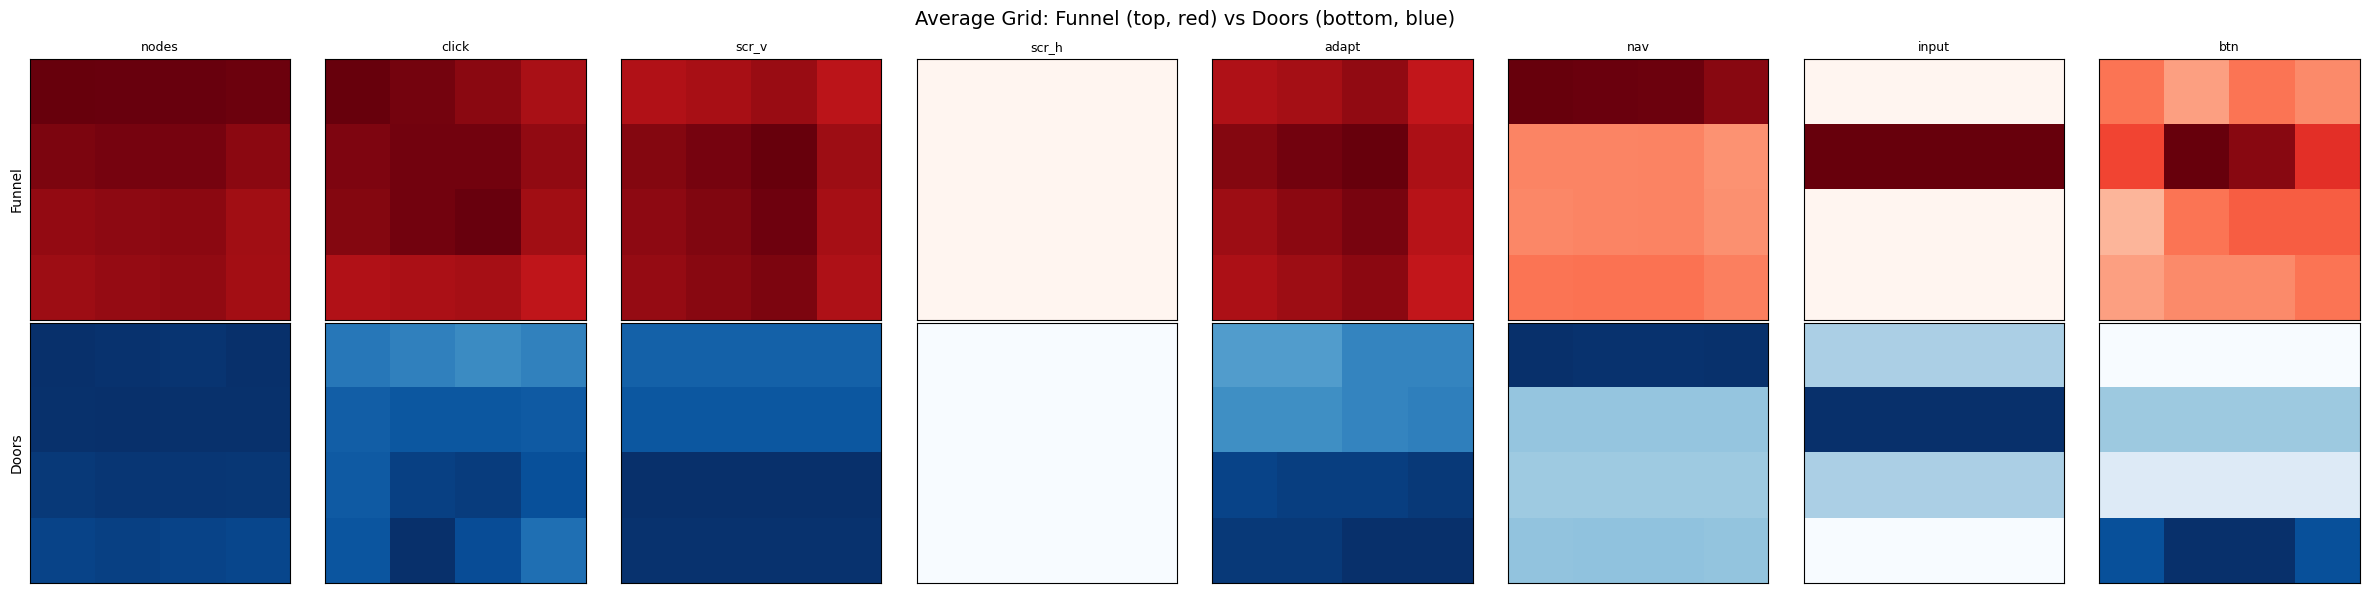

In [4]:
import matplotlib.pyplot as plt
funnel_grids = np.array([d['grid'] for d in data if d['label'] == 0])
doors_grids = np.array([d['grid'] for d in data if d['label'] == 1])
feat_names = ['nodes','click','scr_v','scr_h','adapt','nav','input','btn']
fig, axes = plt.subplots(2, 8, figsize=(24, 6))
fig.suptitle('Average Grid: Funnel (top, red) vs Doors (bottom, blue)', fontsize=14)
for i in range(8):
    axes[0,i].imshow(funnel_grids[:,:,:,i].mean(0), cmap='Reds', vmin=0)
    axes[0,i].set_title(feat_names[i], fontsize=9); axes[0,i].set_xticks([]); axes[0,i].set_yticks([])
    axes[1,i].imshow(doors_grids[:,:,:,i].mean(0), cmap='Blues', vmin=0)
    axes[1,i].set_xticks([]); axes[1,i].set_yticks([])
axes[0,0].set_ylabel('Funnel'); axes[1,0].set_ylabel('Doors')
plt.tight_layout(); plt.show()

## 2. Model

In [5]:
class Attention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.h = heads; self.d = dim // heads; self.s = self.d ** -0.5
        self.qkv = nn.Linear(dim, dim * 3); self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.s
        out = (attn.softmax(-1) @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)

class Block(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = Attention(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        return x + self.mlp(self.n2(x))

class ShovJEPA_Grid(nn.Module):
    def __init__(self, cell_feats=8, dim=64, depth=4, heads=4, pred_depth=2, mask_ratio=0.5, ema=0.996):
        super().__init__()
        self.mask_ratio = mask_ratio; self.ema_val = ema; self.dim = dim
        self.cell_embed = nn.Linear(cell_feats, dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 17, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.encoder = nn.Sequential(*[Block(dim, heads) for _ in range(depth)])
        self.encoder_norm = nn.LayerNorm(dim)
        self.target_embed = copy.deepcopy(self.cell_embed)
        self.target_encoder = copy.deepcopy(self.encoder)
        self.target_norm = copy.deepcopy(self.encoder_norm)
        for p in list(self.target_embed.parameters()) + list(self.target_encoder.parameters()) + list(self.target_norm.parameters()):
            p.requires_grad = False
        pd = dim // 2
        self.pred_in = nn.Linear(dim, pd)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, pd))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.pred_blocks = nn.Sequential(*[Block(pd, heads) for _ in range(pred_depth)])
        self.pred_out = nn.Linear(pd, dim)
        self.shov = nn.Sequential(nn.Linear(dim, 32), nn.GELU(), nn.Linear(32, 3), nn.Sigmoid())

    @torch.no_grad()
    def ema_update(self):
        for ps, pt in [(self.cell_embed.parameters(), self.target_embed.parameters()),
                       (self.encoder.parameters(), self.target_encoder.parameters()),
                       (self.encoder_norm.parameters(), self.target_norm.parameters())]:
            for a, b in zip(ps, pt):
                b.data = self.ema_val * b.data + (1 - self.ema_val) * a.data

    def forward(self, cells, labels=None):
        B = cells.shape[0]; dev = cells.device; N = 16
        nm = int(N * self.mask_ratio)
        mask = torch.ones(B, N, dtype=torch.bool, device=dev)
        for b in range(B): mask[b, torch.randperm(N, device=dev)[:nm]] = False
        x = self.cell_embed(cells)
        x = torch.cat([self.cls_token.expand(B,-1,-1), x], dim=1) + self.pos_embed
        full_mask = torch.cat([torch.ones(B,1,dtype=torch.bool,device=dev), mask], 1)
        x = x * full_mask.unsqueeze(-1).float()
        x = self.encoder_norm(self.encoder(x))
        cls_out = x[:, 0]
        ctx_cells = x[:, 1:]
        coords = self.shov(cls_out)
        s_loss = None
        if labels is not None:
            tgt = torch.zeros(B, 3, device=dev)
            tgt[labels==0] = torch.tensor([0.,1.,1.], device=dev)
            tgt[labels==1] = torch.tensor([1.,0.,0.], device=dev)
            s_loss = F.mse_loss(coords, tgt)
        with torch.no_grad():
            t = self.target_embed(cells)
            t = torch.cat([self.cls_token.expand(B,-1,-1), t], 1) + self.pos_embed
            t = self.target_norm(self.target_encoder(t))
            target_cells = t[:, 1:]
        p = self.pred_in(ctx_cells)
        mt = self.mask_token.expand(B, N, -1)
        m = mask.unsqueeze(-1).float()
        p = p * m + mt * (1 - m)
        p = self.pred_out(self.pred_blocks(p))
        j_loss = torch.tensor(0., device=dev)
        for b in range(B):
            mi = (~mask[b]).nonzero(as_tuple=True)[0]
            if len(mi) > 0: j_loss += F.smooth_l1_loss(p[b,mi], target_cells[b,mi].detach())
        j_loss /= B
        return {'shov_loss':s_loss, 'jepa_loss':j_loss, 'coords':coords.detach(),
                'P':coords[:,0].detach(), 'F':coords[:,1].detach(), 'D':coords[:,2].detach()}

# Smoke test
model = ShovJEPA_Grid().to(device)
test_x = torch.randn(2, 16, 8).to(device)
test_y = torch.tensor([0, 1]).to(device)
test_out = model(test_x, test_y)
print(f'Smoke test OK. Shov={test_out["shov_loss"]:.4f}, JEPA={test_out["jepa_loss"]:.4f}')
tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ShovJEPA_Grid: {tp:,} trainable')

Smoke test OK. Shov=0.2597, JEPA=0.4188
ShovJEPA_Grid: 233,603 trainable


In [7]:
class GridDataset(Dataset):
    def __init__(self, samples, mean=None, std=None):
        X = np.array([s['grid'] for s in samples], dtype=np.float32).reshape(-1, 16, CELL_FEATS)
        self.y = torch.tensor([s['label'] for s in samples], dtype=torch.long)
        if mean is None:
            self.mean = X.mean(axis=(0,1), keepdims=True)
            self.std = X.std(axis=(0,1), keepdims=True) + 1e-8
        else:
            self.mean = mean; self.std = std
        X = (X - self.mean) / self.std
        self.X = torch.tensor(X)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

np.random.seed(42)
idx = np.random.permutation(len(data))
val_n = int(len(data) * 0.2)
train_samples = [data[i] for i in idx[val_n:]]
val_samples = [data[i] for i in idx[:val_n]]
train_ds = GridDataset(train_samples)
val_ds = GridDataset(val_samples, train_ds.mean, train_ds.std)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)
print(f'Train: {len(train_ds)}, Val: {len(val_ds)}')

Train: 320, Val: 80


## 3. Train

In [8]:
EP = 100; JW = 0.5
opt = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EP)
hist = []; best_va = 0

for ep in range(1, EP+1):
    model.train(); tl_s, tl_j, tc, tt = 0, 0, 0, 0
    for X, y in train_dl:
        X, y = X.to(device), y.to(device)
        out = model(X, y)
        loss = out['shov_loss'] + JW * out['jepa_loss']
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); model.ema_update()
        tl_s += out['shov_loss'].item(); tl_j += out['jepa_loss'].item()
        tc += ((out['P']>0.5).long()==y).sum().item(); tt += y.size(0)
    model.eval(); vc, vt = 0, 0; vcoords = []
    with torch.no_grad():
        for X, y in val_dl:
            X, y = X.to(device), y.to(device)
            out = model(X, y)
            vc += ((out['P']>0.5).long()==y).sum().item(); vt += y.size(0)
            vcoords.append(torch.stack([out['P'],out['F'],out['D'],y.float()],1).cpu())
    sch.step()
    ta, va = tc/tt, vc/vt; ndl = len(train_dl)
    hist.append({'ep':ep,'shov_loss':tl_s/ndl,'jepa_loss':tl_j/ndl,'ta':ta,'va':va})
    if va > best_va: best_va = va
    if ep % 20 == 0 or ep == 1:
        print(f'Ep {ep:3d} shov={tl_s/ndl:.4f} jepa={tl_j/ndl:.4f} train={ta:.3f} val={va:.3f}')

print(f'\nBest val: {best_va:.3f}')

Ep   1 shov=0.2393 jepa=0.3450 train=0.594 val=0.650
Ep  20 shov=0.1769 jepa=0.0572 train=0.738 val=0.675
Ep  40 shov=0.1307 jepa=0.0546 train=0.819 val=0.675
Ep  60 shov=0.0846 jepa=0.0651 train=0.869 val=0.662
Ep  80 shov=0.0778 jepa=0.0814 train=0.887 val=0.675
Ep 100 shov=0.0696 jepa=0.0933 train=0.903 val=0.662

Best val: 0.738


## 4. Results

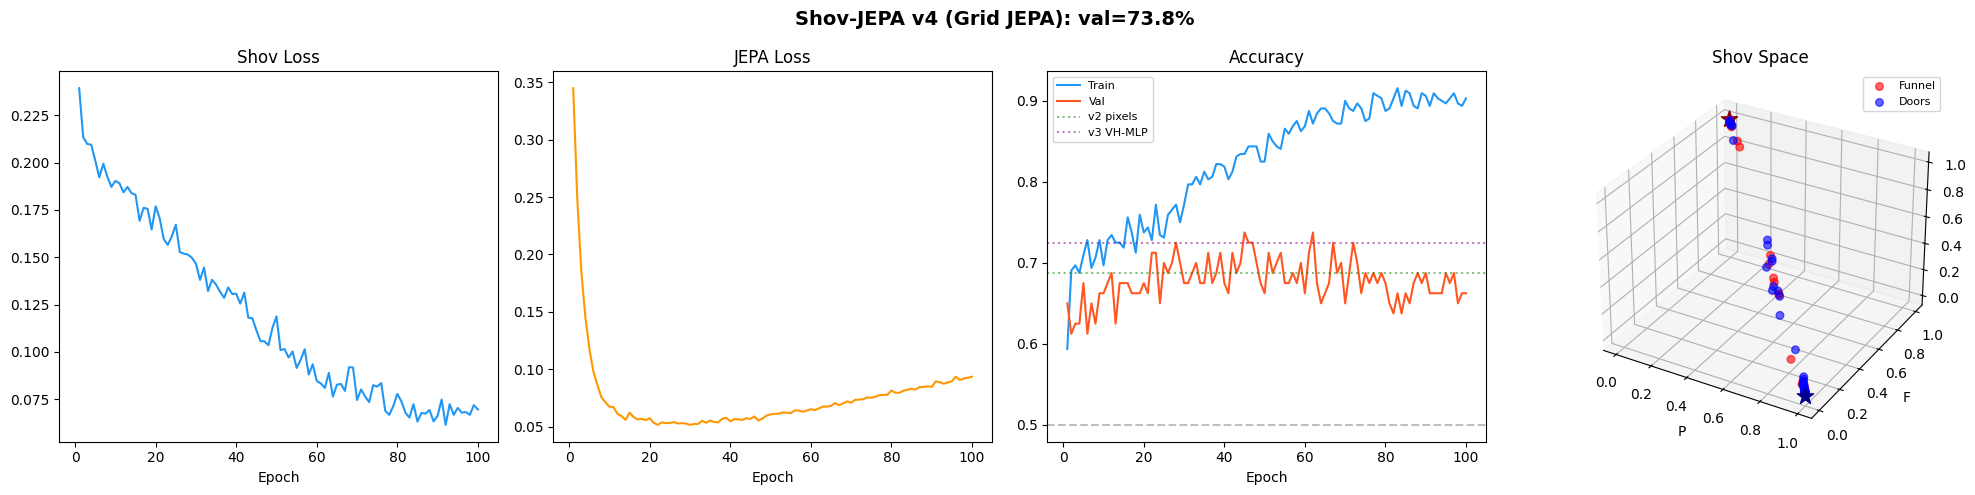

Funnel mean P/F/D: [0.3600371  0.64243484 0.64290786]
Doors  mean P/F/D: [0.68048674 0.3252229  0.32196987]

JEPA loss: 0.3450 → 0.0933 (72.9% reduction)
Model predicts masked cell structure from context!

Model                             Val                Input
------------------------------------------------------------
v2 Shov-JEPA (pixels)           68.8%          224x224 img
v3 Shov-MLP (VH flat)           72.5%          12 features
v4 Shov-JEPA (VH grid)         73.8%            16x8 grid


In [9]:
import matplotlib.pyplot as plt
eps = [h['ep'] for h in hist]
fig = plt.figure(figsize=(20, 5))

ax1 = fig.add_subplot(141)
ax1.plot(eps, [h['shov_loss'] for h in hist], color='#2196F3')
ax1.set_title('Shov Loss'); ax1.set_xlabel('Epoch')

ax2 = fig.add_subplot(142)
ax2.plot(eps, [h['jepa_loss'] for h in hist], color='#FF9800')
ax2.set_title('JEPA Loss'); ax2.set_xlabel('Epoch')

ax3 = fig.add_subplot(143)
ax3.plot(eps, [h['ta'] for h in hist], label='Train', color='#2196F3')
ax3.plot(eps, [h['va'] for h in hist], label='Val', color='#FF5722')
ax3.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax3.axhline(0.688, color='green', ls=':', alpha=0.5, label='v2 pixels')
ax3.axhline(0.725, color='purple', ls=':', alpha=0.5, label='v3 VH-MLP')
ax3.set_title('Accuracy'); ax3.set_xlabel('Epoch'); ax3.legend(fontsize=8)

coords = torch.cat(vcoords, 0).numpy()
fm = coords[:,3]==0; dm = coords[:,3]==1
ax4 = fig.add_subplot(144, projection='3d')
ax4.scatter(coords[fm,0], coords[fm,1], coords[fm,2], c='red', alpha=0.6, s=30, label='Funnel')
ax4.scatter(coords[dm,0], coords[dm,1], coords[dm,2], c='blue', alpha=0.6, s=30, label='Doors')
ax4.scatter([0],[1],[1], c='darkred', marker='*', s=150)
ax4.scatter([1],[0],[0], c='darkblue', marker='*', s=150)
ax4.set_xlabel('P'); ax4.set_ylabel('F'); ax4.set_zlabel('D')
ax4.set_title('Shov Space'); ax4.legend(fontsize=8)

plt.suptitle(f'Shov-JEPA v4 (Grid JEPA): val={best_va:.1%}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Funnel mean P/F/D: {coords[fm,:3].mean(0)}')
print(f'Doors  mean P/F/D: {coords[dm,:3].mean(0)}')

j0 = hist[0]['jepa_loss']; jn = hist[-1]['jepa_loss']
print(f'\nJEPA loss: {j0:.4f} → {jn:.4f} ({(1-jn/j0)*100:.1f}% reduction)')
if jn < j0 * 0.7: print('Model predicts masked cell structure from context!')

print(f'\n{"="*60}')
print(f'{"Model":30s} {"Val":>6s} {"Input":>20s}')
print(f'{"-"*60}')
print(f'{"v2 Shov-JEPA (pixels)":30s} {"68.8%":>6s} {"224x224 img":>20s}')
print(f'{"v3 Shov-MLP (VH flat)":30s} {"72.5%":>6s} {"12 features":>20s}')
print(f'{"v4 Shov-JEPA (VH grid)":30s} {best_va:>5.1%} {"16x8 grid":>20s}')
print(f'{"="*60}')

## 5. Download

In [10]:
results = {
    'experiment': 'v4_grid_jepa',
    'best_val': best_va,
    'history': hist,
    'funnel_mean_PFD': coords[fm,:3].mean(0).tolist(),
    'doors_mean_PFD': coords[dm,:3].mean(0).tolist(),
    'jepa_loss_start': hist[0]['jepa_loss'],
    'jepa_loss_end': hist[-1]['jepa_loss'],
    'all_results': {'v2_pixels':0.688, 'v3_vh_mlp':0.725, 'v4_grid_jepa':best_va}
}
with open(f'{DATA_DIR}/results_v4.json','w') as f: json.dump(results, f, indent=2)
torch.save(model.state_dict(), f'{DATA_DIR}/model_v4.pt')
import shutil
shutil.make_archive('/content/shov_v4', 'zip', DATA_DIR)
from google.colab import files
files.download('/content/shov_v4.zip')
print('Done!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!
